In [5]:
import kwant
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eig
from scipy.optimize import fmin
import os
from matplotlib.colors import Normalize
from matplotlib.colors import TwoSlopeNorm

In [21]:
#function
#ABS
def gr_L(T_l, A_l, check_tol=1e-6):

    N = T_l.shape[0]
    I = np.eye(N)
    Tmat = np.block([
        [np.linalg.inv(T_l) @ A_l, -np.linalg.inv(T_l) @ T_l.conj().T],
        [I, np.zeros((N, N))]
    ])

    eigvals, eigvecs = eig(Tmat)


    idx = np.argsort(np.abs(eigvals))
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]

    lambdas = eigvals[:N]
    vecs = eigvecs[:, :N]

    S1 = vecs[:N, :] 
    S2 = vecs[N:, :]  

    gL = np.linalg.inv(A_l - T_l @ S1 @ np.linalg.inv(S2))
    check = (A_l - T_l @ gL @ T_l.conj().T) @ gL - I
    max_err = np.max(np.abs(check))
    return gL

def zinengr_L(T_LD_wei ,gr_L_wei):
    return T_LD_wei.conj().T @ gr_L_wei @ T_LD_wei

def Gr_DD(H_q,H_l,H_r,  T_12,T_LD,T_l,T_RD,T_r,  N,E,eta=3e-6):
    d = H_q.shape[0]
    I = np.eye(d, dtype=complex)
    Z = np.zeros((d, d), dtype=complex)

    EI_gai = np.block([
        [(E + 1j*eta)*s0, np.zeros((2,2))],
        [np.zeros((2,2)), (E + 1j*eta)*s0]
    ])

    A_l = EI_gai - H_l
    gcl = gr_L(T_l, A_l)
    Sigma_L = zinengr_L(T_LD, gcl)

    A_r = EI_gai - H_r
    gcr = gr_L(T_r, A_r)
    Sigma_R = zinengr_L(T_RD, gcr)


    A_DD = [[Z.copy() for _ in range(N)] for _ in range(N)]

    for i in range(N):

        if i == 0:
            A_DD[i][i] = EI_gai - H_q - Sigma_L
        elif i == N-1:
            A_DD[i][i] = EI_gai - H_q - Sigma_R
        else:
            A_DD[i][i] = EI_gai - H_q

        if i < N-1:
            A_DD[i][i+1] = -T_12

        if i > 0:
            A_DD[i][i-1] = -T_12.conj().T
    A_DD = np.block(A_DD)
    G_DD_r = np.linalg.inv(A_DD)
    return G_DD_r , A_DD ,Sigma_R ,Sigma_L 
    
def bufeng(G_DD_r):
    d = H_q.shape[0]
    yigeshu=np.trace(G_DD_r[q*d:(q+1)*d, (q)*d:(q+1)*d])
    return -np.imag(yigeshu)/np.pi

def find_peaks_fmin(A_of_E, E_min, E_max, N_guess=11, xtol=1e-6, ftol=1e-6, round_digits=6):

    E_guesses = np.linspace(E_min, E_max, N_guess)
    peak_list = []

    for E0 in E_guesses:
        r = fmin(lambda E: -A_of_E(E), E0, disp=False, xtol=xtol, ftol=ftol)
        peak_list.append(r[0])

    peak_list = np.unique(np.round(peak_list, round_digits))
    return peak_list

#current1
def Gr_DD_MS(H_q, H_l, H_r, T_12, T_LD, T_l, T_RD, T_r, N, wn):
    d = H_q.shape[0]
    I = np.eye(d, dtype=complex)
    Z = np.zeros((d, d), dtype=complex)

    EI_gai = np.block([
        [(1j*wn)*s0, np.zeros((2,2))],
        [np.zeros((2,2)), (1j*wn)*s0]
    ])

    A_l = EI_gai - H_l
    gcl = gr_L(T_l, A_l)
    Sigma_L = zinengr_L(T_LD, gcl)

    A_r = EI_gai - H_r
    gcr = gr_L(T_r, A_r)
    Sigma_R = zinengr_L(T_RD, gcr)


    A_DD = [[Z.copy() for _ in range(N)] for _ in range(N)]

    for i in range(N):

        if i == 0:
            A_DD[i][i] = EI_gai - H_q - Sigma_L
        elif i == N-1:
            A_DD[i][i] = EI_gai - H_q - Sigma_R
        else:
            A_DD[i][i] = EI_gai - H_q

        if i < N-1:
            A_DD[i][i+1] = -T_12

        if i > 0:
            A_DD[i][i-1] = -T_12.conj().T

    A_DD_wn = np.block(A_DD)
    G_DD_wn = np.linalg.inv(A_DD_wn)
    return G_DD_wn , A_DD_wn , Sigma_R , Sigma_L 

def J_wn(G_DD_wn, T_12, q):
    d = T_12.shape[0]

    G_q_q1 = G_DD_wn[q*d:(q+1)*d, (q+1)*d:(q+2)*d]
    G_q1_q = G_DD_wn[(q+1)*d:(q+2)*d, q*d:(q+1)*d]

    Jmat = T_12.conj().T @ G_q_q1 - G_q1_q @ T_12
    d_e = d //2
    return np.trace(Jmat[:d_e, :d_e])*(-1j)*KBT*(-1)
    #return np.trace(Jmat)*(-1j)*KBT

def matsubara_list(shumu):
    n_max =  shumu
    n_vals = np.arange(-n_max, n_max+1 )
    wn = (2 * n_vals + 1) * np.pi * KBT

    return wn.tolist()

def J_matsubara_sum(shumu,H_q, H_l, H_r,T_12, T_LD, T_l, T_RD, T_r,N, q):
    wn_list = matsubara_list(shumu)
    J_sum = 0.0 
    for wn in wn_list:
        G_DD_wn, _, _, _ = Gr_DD_MS(
            H_q, H_l, H_r,
            T_12, T_LD, T_l, T_RD, T_r,
            N, wn
        )

        J_sum += np.real(J_wn(G_DD_wn, T_12, q))
    return (J_sum)

def J_of_phi(phi):
    H_l = H_onsite(h,hz,1,phi,0)
    H_q = H_onsite(m,mz,2,phi,zhongjian_saimanjiao)
    H_r = H_onsite(h,hz,3,phi,saimanjiao)
    Jphi = J_matsubara_sum(shumu,H_q, H_l, H_r,T_12, T_LD, T_l, T_RD, T_r,N, q)
    return Jphi

def find_J_extreme_fmin(phi_min=0, phi_max=2*np.pi,
                       N_guess=4, xtol=1e-3, ftol=1e-3,
                       round_digits=6):

    phi_guesses = np.linspace(phi_min, phi_max, N_guess)

    max_list = []
    min_list = []

    for phi0 in phi_guesses:

        rmax = fmin(lambda phi: -J_of_phi(phi), phi0, disp=False, xtol=xtol, ftol=ftol)
        max_list.append(rmax[0])


        rmin = fmin(lambda phi: J_of_phi(phi), phi0, disp=False, xtol=xtol, ftol=ftol)
        min_list.append(rmin[0])

    phi_max_list = np.unique(np.round(max_list, round_digits))
    phi_min_list = np.unique(np.round(min_list, round_digits))

    J_max = -np.inf
    phi_at_Jmax = None
    for phi in phi_max_list:
        val = J_of_phi(phi)
        if val > J_max:
            J_max = val
            phi_at_Jmax = phi

    J_min = np.inf
    phi_at_Jmin = None
    for phi in phi_min_list:
        val = J_of_phi(phi)
        if val < J_min:
            J_min = val
            phi_at_Jmin = phi

    yinzi = (abs(J_max) - abs(J_min)) / (abs(J_max) + abs(J_min) + 1e-12)

    return J_max, phi_at_Jmax/np.pi, J_min, phi_at_Jmin/np.pi, yinzi

def JoseCurrent_E_lmsm(E,H_l,H_r,H_q,T_l,T_r,T_12,T_RD,T_LD):
    G_DD_r , A_DD ,Sigma_R ,Sigma_L=Gr_DD(H_q,H_l,H_r,  T_12,T_LD,T_l,T_RD,T_r,  N,E,eta=1e-3)
    G_xiao=1/(1+np.exp((E - mu)/KBT))*(G_DD_r.conj().T-G_DD_r)

    d = T_12.shape[0]
    G_0_1 = G_xiao[q*d:(q+1)*d, (q+1)*d:(q+2)*d]
    G_1_0= G_xiao[(q+1)*d:(q+2)*d, q*d:(q+1)*d]
    Jmat = T_12 @ G_1_0 - T_12.conj().T @ G_0_1
    return np.trace(Jmat)

def JoseCurrent_E(E,H_l,H_r,H_q,T_l,T_r,T_12,T_RD,T_LD,xuxubu):
    G_DD_r , A_DD ,Sigma_R ,Sigma_L=Gr_DD(H_q,H_l,H_r,  T_12,T_LD,T_l,T_RD,T_r,  N,E,eta=xuxubu)
    d = T_12.shape[0]

    zineng_DD_less_then = np.zeros((d*N, d*N), dtype=complex)
    zineng_DD_less_then[0:4, 0:4]=-2j*(np.imag(Sigma_L))*(1/(1+np.exp((E-mu) /KBT)))
    zineng_DD_less_then[(N-1)*4:4*N, (N-1)*4:4*N]=-2j*(np.imag(Sigma_R))*(1/(1+np.exp((E-mu) / KBT)))
    G_xiao=G_DD_r @ zineng_DD_less_then @ G_DD_r.conj().T

    
    G_0_1 = G_xiao[q*d:(q+1)*d, (q+1)*d:(q+2)*d]
    G_1_0= G_xiao[(q+1)*d:(q+2)*d, q*d:(q+1)*d]
    Jmat = T_12 @ G_1_0 - T_12.conj().T @ G_0_1
    return np.real(np.trace(Jmat)/(2*np.pi))



In [ ]:
#参数1
dela = 1
t = 200   #[150,400] 300
af =50 # 【0，50】 35
a = 1
mu = 0
chaodaojiao=np.pi*0

#两边
hz=0.95
hc=0.5   #两边的长度一样
if hc>1:
    print('stop')
h =hc * np.sqrt(mu**2 + dela**2)
saimanjiao = np.pi*0

#中间
mz=hz
m = h
zhongjian_saimanjiao=np.pi*0

T_Tc=0.1
Delta = dela * np.tanh(1.74 * np.sqrt(1 / T_Tc - 1))
dianshubei=2#8
KBT=2 * dela * T_Tc / 3.5
shumu=int(np.floor(50*dela/(2*np.pi*KBT)))*dianshubei


N=2
Lx=N
q=0
epp=1e-3j
#矩阵信息
sx = np.array([[0, 1], [1, 0]], complex)
sy = np.array([[0, -1j], [1j, 0]], complex)
sz = np.array([[1, 0], [0, -1]], complex)
s0 = np.array([[1, 0], [0, 1]], complex)

def H_onsite(m_xy,m_z,weizhi,chaodaojiao,Bjiao,renyixiang=0):
    if weizhi==1:
        Delta_X= Delta * np.exp(1j*renyixiang) * 1j * sy
    elif weizhi==2:
        Delta_X=np.zeros((2,2))
    elif weizhi==3:
        Delta_X= Delta * np.exp(-1j*chaodaojiao) * 1j * sy
    HX_block=-(mu-2*t)*s0 + m_xy*np.sin(Bjiao)*sy+ m_xy*np.cos(Bjiao)*sx + m_z*sz
    return np.block([
        [ HX_block,        Delta_X       ],
        [ Delta_X.conj().T, -HX_block.conj() ]
    ])
def H_hop(af):
    H_X_right_to_left_hop_block=-1*(t*s0+1j*af*sz/(a))
    return np.block([
        [ H_X_right_to_left_hop_block,        np.zeros((2,2))],
        [ np.zeros((2,2)), -H_X_right_to_left_hop_block.conj() ]
    ])
#左边矩阵信息
H_L_onsite=H_onsite(h,hz,1,chaodaojiao,0)
H_L_right_to_left_hop=H_hop(af)

#中间矩阵信息
H_center_to_L=H_hop(af)

H_center=H_onsite(m,mz,2,chaodaojiao,zhongjian_saimanjiao)
H_center_right_to_left_hop=H_hop(af)

H_R_to_center=H_hop(af)

#右边矩阵信息
H_R_onsite=H_onsite(h,hz,3,chaodaojiao,saimanjiao)
H_R_right_to_left_hop=H_hop(af)

#输入矩阵
H_q=H_center
T_12= H_center_right_to_left_hop.conj().T

H_l= H_L_onsite
T_l= H_L_right_to_left_hop

H_r= H_R_onsite
T_r=H_R_right_to_left_hop.conj().T

T_LD=H_center_to_L.conj().T
T_RD= H_R_to_center

#shumu*2*np.pi*KBT/Delta

In [10]:
save_dir = rf"D:\结果\2026.3.13\hz={hz},T_c={T_Tc},hc={hc}"
os.makedirs(save_dir, exist_ok=True)
def save_fig_by_title(name):

    for ch in ['\\','/',':','*','?','"','<','>','|']:
        name = name.replace(ch,'_')

    filename = os.path.join(save_dir, name + ".png")

    plt.savefig(filename, dpi=300, bbox_inches='tight')
save=False

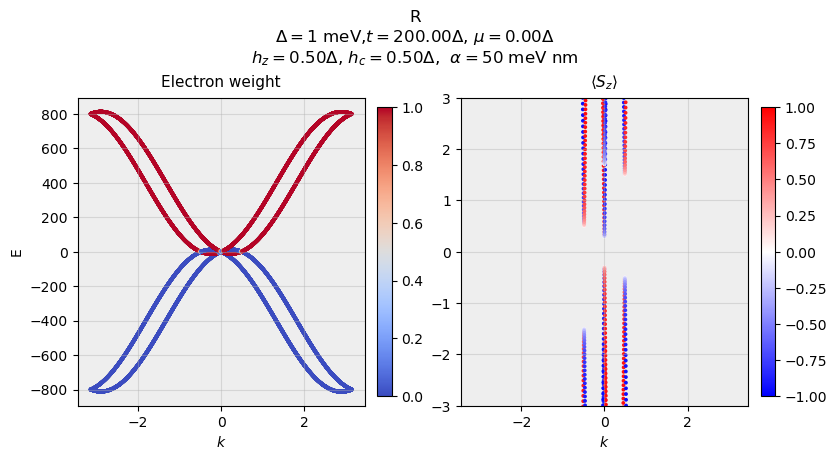

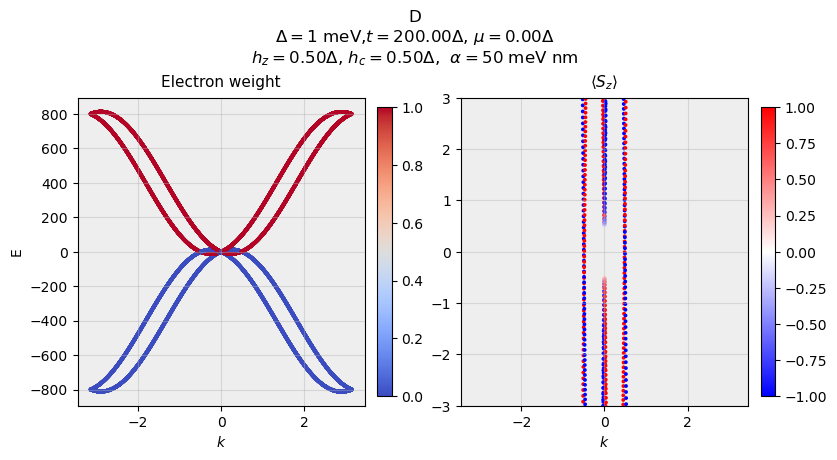

In [32]:
#nengdai
P_e = np.diag([1, 1, 0, 0])
P_h = np.diag([0, 0, 1, 1])   
Sz = np.block([
    [sz, np.zeros((2,2))],
    [np.zeros((2,2)), 1*sz]
])

ks = np.linspace(-np.pi, np.pi, 6001)

def Hk(k, H, T):
    return H + T * np.exp(1j*k) + T.conj().T * np.exp(-1j*k)

for H_d, T_d, weizhi in zip([H_r,H_q] , [T_r,T_12], ['R','D']):
    energies = []
    electron_weight = []
    spin_expect = []

    for k in ks:
        H_k = Hk(k, H_d, T_d)
        evals, evecs = np.linalg.eigh(H_k)
        energies.append(evals)

        for n in range(len(evals)):
            psi = evecs[:, n]
            w_e = np.real(psi.conj().T @ P_e @ psi)
            s_z = np.real(psi.conj().T @ Sz @ psi)
            electron_weight.append(w_e)
            spin_expect.append(s_z)

    energies        = np.array(energies)
    electron_weight = np.array(electron_weight).reshape(len(ks), -1)
    spin_expect     = np.array(spin_expect).reshape(len(ks), -1)

    # ────────────── 画图：左右并排 ──────────────
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 4),  # 宽度加倍
                                sharey=False,           # 共用 y 轴刻度
                                gridspec_kw={'wspace': 0.22})

    # 统一背景
    ax1.set_facecolor('#eeeeee')
    ax2.set_facecolor('#eeeeee')

    # ── 左图：Electron weight ──
    norm_e = Normalize(vmin=0, vmax=1)
    for n in range(energies.shape[1]):
        sc1 = ax1.scatter(ks, energies[:, n],
                        c=electron_weight[:, n],
                        cmap='coolwarm',
                        norm=norm_e,
                        s=3, rasterized=True)

    ax1.set_xlabel(r'$k$')
    ax1.set_ylabel('E')
    ax1.set_title('Electron weight', fontsize=11, pad=8)
    ax1.grid(True, alpha=0.4)
    cbar1 = fig.colorbar(sc1, ax=ax1, fraction=0.046, pad=0.04)
    #cbar1.set_label('Electron weight')

    # ── 右图：⟨Sz⟩ ──
    norm_s = TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)
    for n in range(energies.shape[1]):
        sc2 = ax2.scatter(ks, energies[:, n],
                        c=spin_expect[:, n],
                        cmap='bwr',
                        norm=norm_s,
                        s=3, rasterized=True)

    ax2.set_xlabel(r'$k$')
    # ax2.set_ylabel('E')   # 因为 sharey=True，左边已有 y 轴
    ax2.set_title(r'$\langle S_z \rangle$', fontsize=11, pad=8)
    ax2.grid(True, alpha=0.4)
    cbar2 = fig.colorbar(sc2, ax=ax2, fraction=0.046, pad=0.04)
    #cbar2.set_label(r'$\langle S_z \rangle$')

    # ── 统一主标题（参数信息） ──
    title_text = (
        f'{weizhi}\n'
        f'$\\Delta = {dela}$ meV,$t = {t/dela:.2f}\\Delta$, $\\mu = {mu/dela:.2f}\\Delta$\n'
        f'$h_z = {hz:.2f}\\Delta$, $h_c = {h:.2f}\\Delta$,  $\\alpha = {af}$ meV nm'
    )
    fig.suptitle(title_text, fontsize=12, y=1.1)

    # 可选：统一 y 范围（根据需要打开）
    ylimit = (-dela*3, dela*3)
    #ax1.set_ylim(ylimit)
    ax2.set_ylim(ylimit)

    # ── 显示 / 保存 ──
    if save:
        save_fig_by_title(f"{weizhi}")     
    plt.show()

<>:45: SyntaxWarning: invalid escape sequence '\D'
<>:45: SyntaxWarning: invalid escape sequence '\D'
C:\Users\taoji\AppData\Local\Temp\ipykernel_12696\2679117168.py:45: SyntaxWarning: invalid escape sequence '\D'
  plt.ylabel('E/$\Delta$')


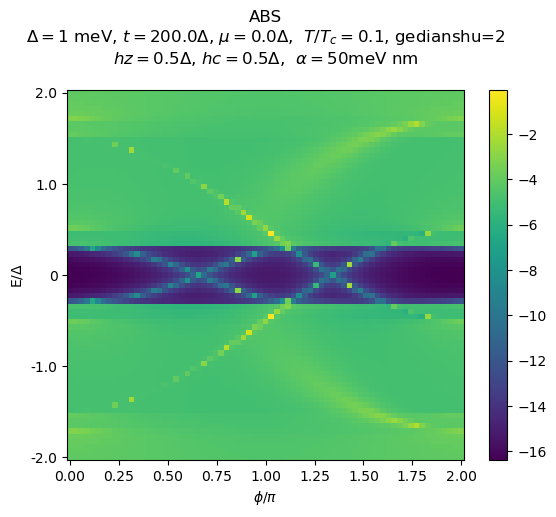

In [33]:
#ABS
num_ef = 70
efmin = -Delta*2
efmax = Delta*2
def_ = (efmax - efmin) / num_ef
num_phi = 70
phi_min = 0
phi_max = 2 * np.pi
dphi = (phi_max - phi_min) / num_phi

# Initialize grids
ef_plot = np.zeros(num_ef + 1)
phi_plot = np.zeros(num_phi + 1)
ABS = np.zeros((num_ef + 1, num_phi + 1))

for jj in range(num_ef + 1):
    ef = efmin + def_ * jj
    ef_plot[jj] = ef
    for ii in range(num_phi + 1):
        phi = phi_min + dphi * ii
        phi_plot[ii] = phi / np.pi
        
        # Update Delta and H_l, H_r based on phi
        H_r = H_onsite(h,hz,3,phi,saimanjiao)
        
        # Compute G_DD_r
        G_DD_r, _, _, _ = Gr_DD(
            H_q, H_l, H_r,
            T_12, T_LD, T_l, T_RD, T_r,
            N, ef
        )
        
        # Compute ABS (bufeng)
        ABS[jj, ii] = bufeng(G_DD_r)

# Figure
plt.figure()


X, Y = np.meshgrid(phi_plot, ef_plot)
plt.pcolormesh(X, Y, np.log(ABS + 1e-10), shading='auto')  # Added small epsilon to avoid log(0)
plt.colorbar()
plt.xlabel(r'$\phi$/$\pi$')

plt.ylabel('E/$\Delta$')
plt.yticks(
    [efmin, efmin/2, 0,efmax/2, efmax],
    [efmin/Delta, efmin*0.5/Delta, 0,efmax*0.5/Delta, efmax/Delta]
)
plt.title(
    f'ABS\n'
    f'$\\Delta = {dela}$ meV, $t = {t/dela}\\Delta$, $\\mu = {mu/dela}\\Delta$,  $T/T_c = {T_Tc}$, gedianshu=2\n'
    f'$hz = {hz}\\Delta$, $hc = {h}\\Delta$,  $\\alpha = {af}$meV nm\n'
    
)
plt.axis('square')
plt.axis('tight')
if save:
    save_fig_by_title(f"ABS")   
plt.show()


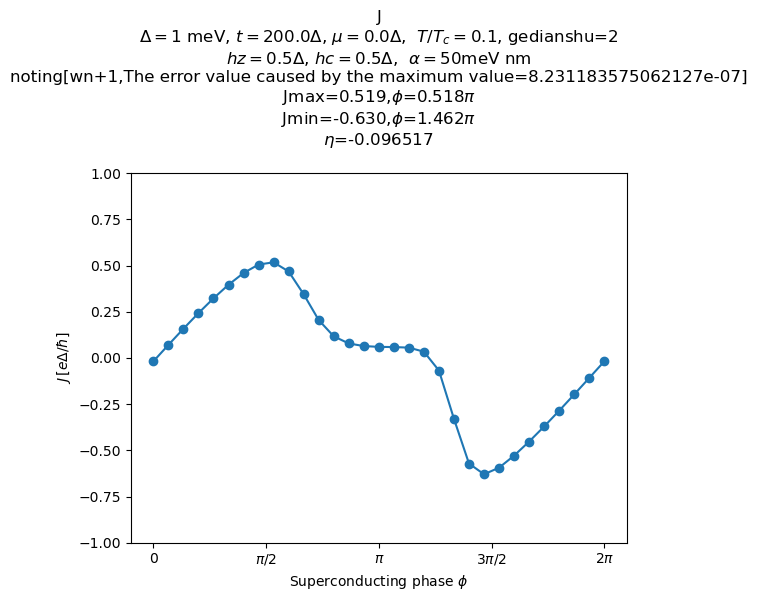

In [34]:
#J vs phi
phi_list = np.linspace(0, 2*np.pi, 31)
J_list = []
for phi in phi_list:

    chaodaojiao = phi
    H_r = H_onsite(h,hz,3,chaodaojiao,saimanjiao)
    Jphi = J_matsubara_sum(shumu,H_q, H_l, H_r,T_12, T_LD, T_l, T_RD, T_r,N, q)

    J_list.append(Jphi)

jjalpi=J_of_phi(0.5*np.pi)
shumu=int(np.floor(50*dela/(2*np.pi*KBT)))*dianshubei+1
jjalpi2=J_of_phi(0.5*np.pi)
alnalkna=abs(abs(jjalpi2)-abs(jjalpi))/(abs(jjalpi2)+abs(jjalpi))

shumu=int(np.floor(50*dela/(2*np.pi*KBT)))*dianshubei
a2,a3,a4,a5,a6=find_J_extreme_fmin(phi_min=0.5*np.pi, phi_max=1.5*np.pi,
                N_guess=2, xtol=1e-3, ftol=1e-3,
                round_digits=6)

plt.figure()
plt.plot(phi_list, J_list, marker='o')
plt.xlabel(r'Superconducting phase $\phi$')
plt.ylabel(r'$J\,[e\Delta/\hbar]$')
plt.xticks(
    [0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi],
    ['0', r'$\pi/2$', r'$\pi$', r'$3\pi/2$', r'$2\pi$']
)
plt.title(
    f'J\n'
    f'$\\Delta = {dela}$ meV, $t = {t/dela}\\Delta$, $\\mu = {mu/dela}\\Delta$,  $T/T_c = {T_Tc}$, gedianshu=2\n'
    f'$hz = {hz}\\Delta$, $hc = {h}\\Delta$,  $\\alpha = {af}$meV nm\n'
    f'noting[wn+1,The error value caused by the maximum value={alnalkna}]\n'
    f'Jmax={a2:.3f},$\\phi$={a3:.3f}$\\pi$\n'
    f'Jmin={a4:.3f},$\\phi$={a5:.3f}$\\pi$\n'
    f'$\\eta$={a6:.6f}\n'
    
)
plt.ylim(-1,1)
if save:
    save_fig_by_title("J vs phi")
plt.show()

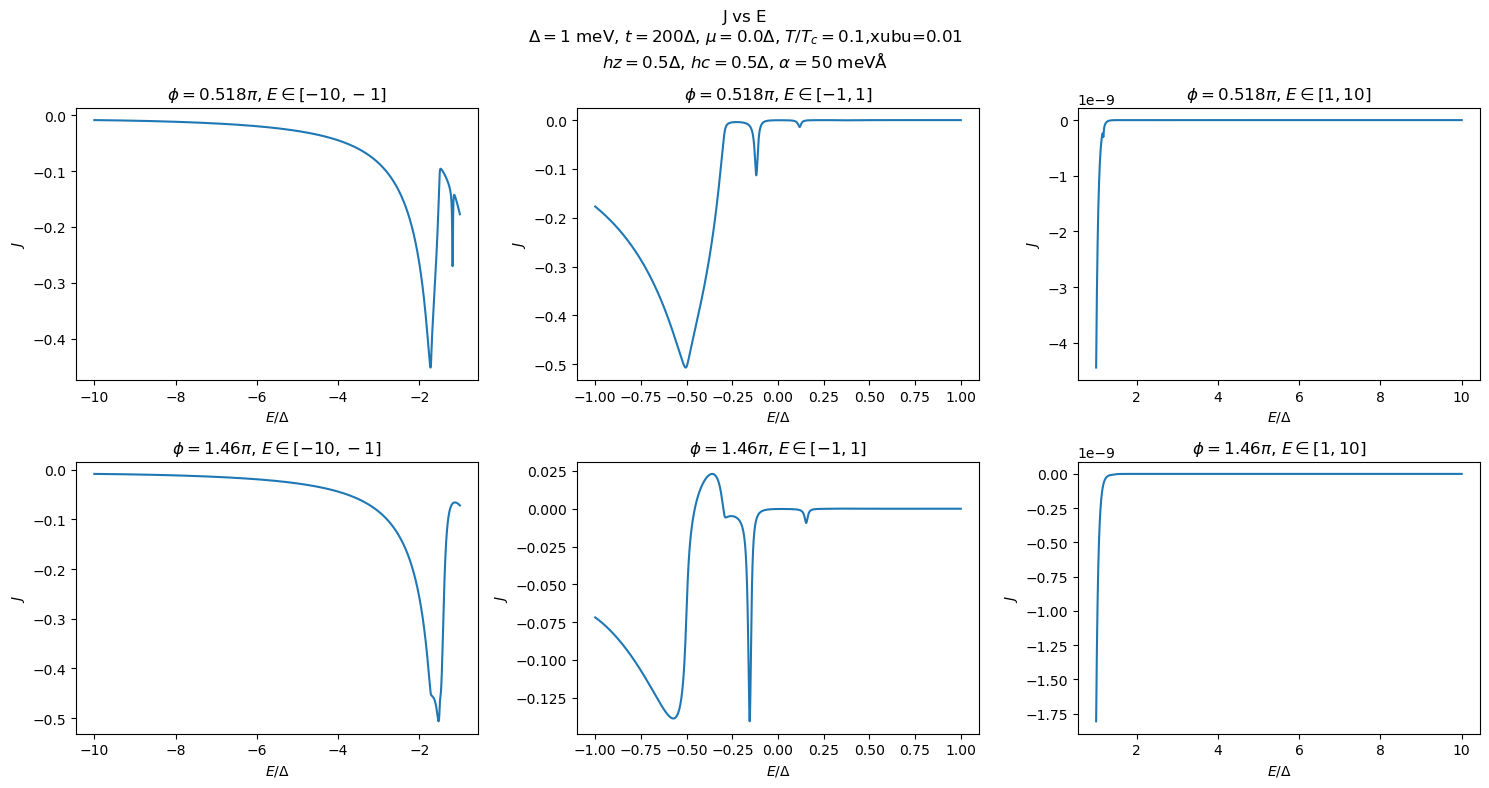

In [35]:
#J vs E
plt.figure(figsize=(15,8))

jieduan=10
xuxubu=1e-2
# ================= 相位1 =================
chaodaojiao = np.pi*(a3)

H_R_onsite = H_onsite(h,hz,3,chaodaojiao,saimanjiao)
H_r = H_R_onsite


# -------- 图1  E∈[-1,1] --------
plt.subplot(2,3,2)

E_set = np.linspace(-1,1,2000)
J=[]
for E in E_set:
    J.append(JoseCurrent_E(E,H_l,H_r,H_q,T_l,T_r,T_12,T_RD,T_LD,xuxubu))

plt.plot(E_set,J)

plt.title(rf"$\phi={(a3):.3f}\pi$, $E\in[-1,1]$")
plt.xlabel(r"$E/\Delta$")
plt.ylabel(r"$J$")


# -------- 图2  E∈[-50,-1] --------
plt.subplot(2,3,1)

E_set = np.linspace(-jieduan,-1,2000)
J=[]
for E in E_set:
    J.append(JoseCurrent_E(E,H_l,H_r,H_q,T_l,T_r,T_12,T_RD,T_LD,xuxubu))

plt.plot(E_set,J)

plt.title(rf"$\phi={(a3):.3f}\pi$, $E\in[-{jieduan},-1]$")
plt.xlabel(r"$E/\Delta$")
plt.ylabel(r"$J$")

# -------- 图3  E∈[1,50] --------
plt.subplot(2,3,3)

E_set = np.linspace(1,jieduan,2000)
J=[]
for E in E_set:
    J.append(JoseCurrent_E(E,H_l,H_r,H_q,T_l,T_r,T_12,T_RD,T_LD,xuxubu))

plt.plot(E_set,J)

plt.title(rf"$\phi={a3:.3f}\pi$, $E\in[1,{jieduan}]$") 
plt.xlabel(r"$E/\Delta$")
plt.ylabel(r"$J$")


# ================= 相位2 =================
chaodaojiao = np.pi*(a5)

H_R_onsite = H_onsite(h,hz,3,chaodaojiao,saimanjiao)
H_r = H_R_onsite


# -------- 图4  E∈[-1,1] --------
plt.subplot(2,3,5)

E_set = np.linspace(-1,1,2000)
J=[]
for E in E_set:
    J.append(JoseCurrent_E(E,H_l,H_r,H_q,T_l,T_r,T_12,T_RD,T_LD,xuxubu))

plt.plot(E_set,J)

plt.title(rf"$\phi={a5:.2f}\pi$, $E\in[-1,1]$")
plt.xlabel(r"$E/\Delta$")
plt.ylabel(r"$J$")


# -------- 图5  E∈[-50,-1] --------
plt.subplot(2,3,4)

E_set = np.linspace(-jieduan,-1,2000)
J=[]
for E in E_set:
    J.append(JoseCurrent_E(E,H_l,H_r,H_q,T_l,T_r,T_12,T_RD,T_LD,xuxubu))

plt.plot(E_set,J)

plt.title(rf"$\phi={a5:.2f}\pi$, $E\in[-{jieduan},-1]$")
plt.xlabel(r"$E/\Delta$")
plt.ylabel(r"$J$")

# -------- 图6  E∈[1,50] --------
plt.subplot(2,3,6)

E_set = np.linspace(1,jieduan,2000)
J=[]
for E in E_set:
    J.append(JoseCurrent_E(E,H_l,H_r,H_q,T_l,T_r,T_12,T_RD,T_LD,xuxubu))

plt.plot(E_set,J)

plt.title(rf"$\phi={a5:.2f}\pi$, $E\in[1,{jieduan}]$")
plt.xlabel(r"$E/\Delta$")
plt.ylabel(r"$J$")

# ================= 总标题 =================
plt.suptitle(
    f'J vs E\n'
    f'$\\Delta = {dela}$ meV, $t={t}\\Delta$, '
    f'$\\mu = {mu/dela}\\Delta$, $T/T_c = {T_Tc}$,xubu={xuxubu}\n'
    f'$hz = {hz}\\Delta$, $hc = {h}\\Delta$, $\\alpha = {af}$ meVÅ'
)

plt.tight_layout()
if save:
    save_fig_by_title("J vs E")
plt.show()

In [3]:
# ====================== 通用优化函数======================
PARAMETERS = ['hz', 'mz', 'm', 'h', 'saimanjiao', 'zhongjian_saimanjiao', 'af']

def abs_yinzi_of(param_name, param_val, mode='both', range_min=0.5, range_max=2.0):
    """
    param_name: 要优化的参数
    mode: 'max'（只找最大yinzi）、'min'（只找最小yinzi）、'both'（默认）
    range_min / range_max: 超出这个范围就立刻结束搜索（你要求的 0.7*2 ~ 1*2）
    """
    if param_name not in PARAMETERS:
        raise ValueError(f"不支持的参数: {param_name}")

    # 备份旧值
    old_val = globals()[param_name]

    # 强制转标量（fmin 会传 ndarray）
    if isinstance(param_val, np.ndarray):
        param_val = float(param_val.item())

    # ===== 范围检查：超出 1.4~2.0 就直接返回惩罚值，让 fmin 自动跳出 =====
    if param_val < range_min or param_val > range_max:
        if mode == 'max':
            return -100.0          # 对找最大非常不利
        elif mode == 'min':
            return 100.0           # 对找最小非常不利
        else:
            return 0.0

    # 临时修改全局变量
    globals()[param_name] = param_val
    if param_name == 'h':
        globals()['h'] = param_val

    try:
        _, _, _, _, yinzi = find_J_extreme_fmin(
            phi_min=0, phi_max=2*np.pi, N_guess=4, xtol=1e-3, ftol=1e-3
        )
        val = abs(yinzi)
        if isinstance(val, np.ndarray):
            val = float(val.item())

        print(f"{param_name} = {param_val:.6f}  |yinzi| = {val:.6f}")
        return val
    finally:
        globals()[param_name] = old_val
        if param_name == 'h':
            globals()['h'] = old_val


def find_yinzi_extreme(param_name, param_min, param_max,
                       mode='both',          # ← 新增：选择只找最大/最小/两者
                       range_min=0.5, range_max=2.0,   # ← 你要求的范围，超出自动结束
                       N_guess=1, xtol=1e-2, ftol=1e-3, round_digits=6):
    """
    mode='max'   → 只找最大 yinzi
    mode='min'   → 只找最小 yinzi
    mode='both'  → 同时找最大和最小（默认）
    """
    print(f"开始优化 {param_name}（范围 {param_min}~{param_max}，mode={mode}）...")

    guesses = np.linspace(param_min, param_max, N_guess)

    max_list = []
    min_list = []

    global_best_max = -np.inf
    best_val = None
    global_best_min = np.inf
    worst_val = None

    for val0 in guesses:
        print(f"\n===== guess {param_name} = {val0:.6f} =====")

        if mode in ['max', 'both']:
            rmax = fmin(lambda v: -abs_yinzi_of(param_name, v, mode, range_min, range_max),
                        val0, disp=False, xtol=xtol, ftol=ftol)
            max_list.append(rmax[0])

        if mode in ['min', 'both']:
            rmin = fmin(lambda v: abs_yinzi_of(param_name, v, mode, range_min, range_max),
                        val0, disp=False, xtol=xtol, ftol=ftol)
            min_list.append(rmin[0])

    # 精确计算最终极值
    val_list = np.unique(np.round(max_list + min_list, round_digits))

    for val in val_list:
        v = abs_yinzi_of(param_name, val, mode, range_min, range_max)
        if v > global_best_max:
            global_best_max = v
            best_val = val
        if v < global_best_min:
            global_best_min = v
            worst_val = val
    print("\n====== FINAL RESULT ======")
    print(f"优化参数: {param_name}   mode={mode}")

    if mode in ['max', 'both']:
        print(f"max |yinzi| = {global_best_max:.6f}  at {param_name} = {best_val}")

    if mode in ['min', 'both']:
        print(f"min |yinzi| = {global_best_min:.6f}  at {param_name} = {worst_val}")
    return global_best_max, best_val, global_best_min, worst_val


# ====================== 使用示例（直接运行下面一行即可） ======================

# 示例1：只找最大 yinzi（hz 在 0.7~2.0 范围内）

# 示例2：只找最小 yinzi
# yinzi_min, _, worst_val, _ = find_yinzi_extreme('hz', 0.7, 2.0, mode='min')

# 示例3：同时找最大和最小（默认）
# yinzi_max, best_val, yinzi_min, worst_val = find_yinzi_extreme('hz', 0.7, 2.0, mode='both')

# 换其他参数只需改第一个字符串：
# find_yinzi_extreme('mz', 0.0, 2.0, mode='max')
# find_yinzi_extreme('af', 50, 150, mode='min')

<>:245: SyntaxWarning: invalid escape sequence '\D'
<>:245: SyntaxWarning: invalid escape sequence '\D'
C:\Users\taoji\AppData\Local\Temp\ipykernel_12696\906963199.py:245: SyntaxWarning: invalid escape sequence '\D'
  plt.ylabel('E/$\Delta$')


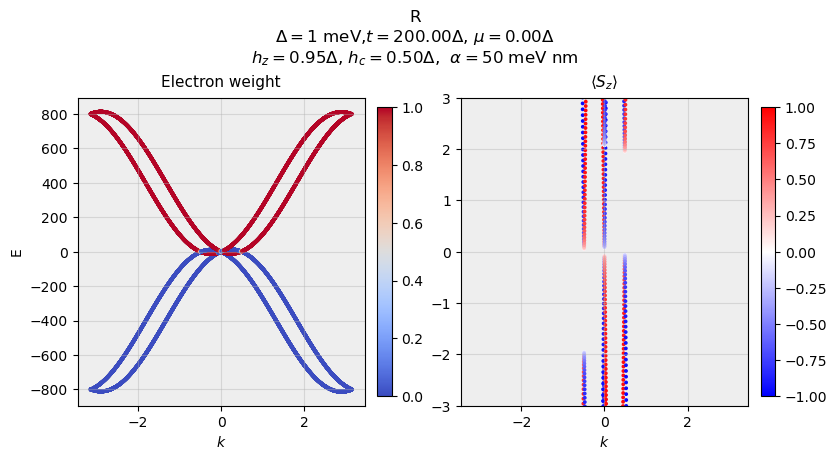

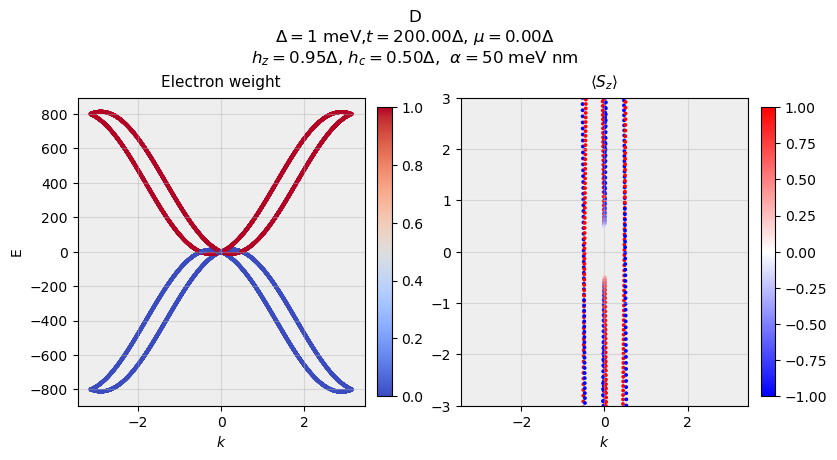

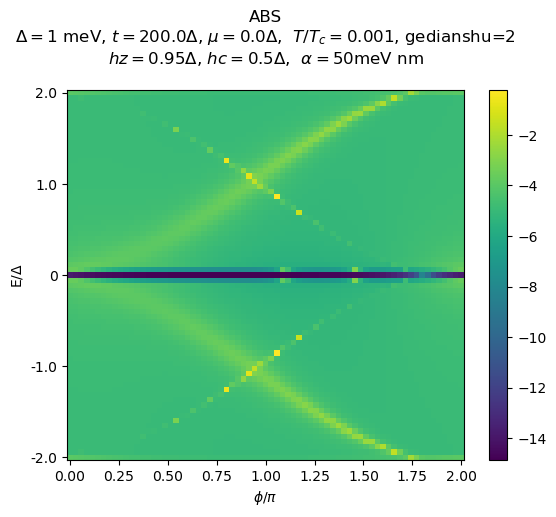

In [ ]:
save=True
for hz in [0.95]:
    #参数1
    dela = 1
    t = 200   #[150,400] 300
    af =50 # 【0，50】 35
    a = 1
    mu = 0
    chaodaojiao=np.pi*0

    #两边
    hc=0.5   #两边的长度一样
    if hc>1:
        print('stop')
    h =hc * np.sqrt(mu**2 + dela**2)
    saimanjiao = np.pi*0

    #中间
    mz=hz
    m = h
    zhongjian_saimanjiao=np.pi*0

    T_Tc=0.001
    Delta = dela * np.tanh(1.74 * np.sqrt(1 / T_Tc - 1))
    dianshubei=2#8
    KBT=2 * dela * T_Tc / 3.5
    shumu=int(np.floor(50*dela/(2*np.pi*KBT)))*dianshubei


    N=2
    Lx=N
    q=0
    epp=1e-3j
    #矩阵信息
    sx = np.array([[0, 1], [1, 0]], complex)
    sy = np.array([[0, -1j], [1j, 0]], complex)
    sz = np.array([[1, 0], [0, -1]], complex)
    s0 = np.array([[1, 0], [0, 1]], complex)

    def H_onsite(m_xy,m_z,weizhi,chaodaojiao,Bjiao,renyixiang=0):
        if weizhi==1:
            Delta_X= Delta * np.exp(1j*renyixiang) * 1j * sy
        elif weizhi==2:
            Delta_X=np.zeros((2,2))
        elif weizhi==3:
            Delta_X= Delta * np.exp(-1j*chaodaojiao) * 1j * sy
        HX_block=-(mu-2*t)*s0 + m_xy*np.sin(Bjiao)*sy+ m_xy*np.cos(Bjiao)*sx + m_z*sz
        return np.block([
            [ HX_block,        Delta_X       ],
            [ Delta_X.conj().T, -HX_block.conj() ]
        ])
    def H_hop(af):
        H_X_right_to_left_hop_block=-1*(t*s0+1j*af*sz/(a))
        return np.block([
            [ H_X_right_to_left_hop_block,        np.zeros((2,2))],
            [ np.zeros((2,2)), -H_X_right_to_left_hop_block.conj() ]
        ])
    #左边矩阵信息
    H_L_onsite=H_onsite(h,hz,1,chaodaojiao,0)
    H_L_right_to_left_hop=H_hop(af)

    #中间矩阵信息
    H_center_to_L=H_hop(af)

    H_center=H_onsite(m,mz,2,chaodaojiao,zhongjian_saimanjiao)
    H_center_right_to_left_hop=H_hop(af)

    H_R_to_center=H_hop(af)

    #右边矩阵信息
    H_R_onsite=H_onsite(h,hz,3,chaodaojiao,saimanjiao)
    H_R_right_to_left_hop=H_hop(af)

    #输入矩阵
    H_q=H_center
    T_12= H_center_right_to_left_hop.conj().T

    H_l= H_L_onsite
    T_l= H_L_right_to_left_hop

    H_r= H_R_onsite
    T_r=H_R_right_to_left_hop.conj().T

    T_LD=H_center_to_L.conj().T
    T_RD= H_R_to_center

    #shumu*2*np.pi*KBT/Delta
    save_dir = rf"D:\结果\2026.3.14\hz={hz},T_c={T_Tc},hc={hc}"
    os.makedirs(save_dir, exist_ok=True)
    def save_fig_by_title(name):

        for ch in ['\\','/',':','*','?','"','<','>','|']:
            name = name.replace(ch,'_')

        filename = os.path.join(save_dir, name + ".png")

        plt.savefig(filename, dpi=300, bbox_inches='tight')


    ######################################################################################

    P_e = np.diag([1, 1, 0, 0])
    P_h = np.diag([0, 0, 1, 1])   
    Sz = np.block([
        [sz, np.zeros((2,2))],
        [np.zeros((2,2)), 1*sz]
    ])

    ks = np.linspace(-np.pi, np.pi, 6001)

    def Hk(k, H, T):
        return H + T * np.exp(1j*k) + T.conj().T * np.exp(-1j*k)

    for H_d, T_d, weizhi in zip([H_r,H_q],[T_r,T_12],['R','D']):
        energies = []
        electron_weight = []
        spin_expect = []

        for k in ks:
            H_k = Hk(k, H_d, T_d)
            evals, evecs = np.linalg.eigh(H_k)
            energies.append(evals)

            for n in range(len(evals)):
                psi = evecs[:, n]
                w_e = np.real(psi.conj().T @ P_e @ psi)
                s_z = np.real(psi.conj().T @ Sz @ psi)
                electron_weight.append(w_e)
                spin_expect.append(s_z)

        energies        = np.array(energies)
        electron_weight = np.array(electron_weight).reshape(len(ks), -1)
        spin_expect     = np.array(spin_expect).reshape(len(ks), -1)

        # ────────────── 画图：左右并排 ──────────────
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 4),  # 宽度加倍
                                    sharey=False,           # 共用 y 轴刻度
                                    gridspec_kw={'wspace': 0.22})

        # 统一背景
        ax1.set_facecolor('#eeeeee')
        ax2.set_facecolor('#eeeeee')

        # ── 左图：Electron weight ──
        norm_e = Normalize(vmin=0, vmax=1)
        for n in range(energies.shape[1]):
            sc1 = ax1.scatter(ks, energies[:, n],
                            c=electron_weight[:, n],
                            cmap='coolwarm',
                            norm=norm_e,
                            s=3, rasterized=True)

        ax1.set_xlabel(r'$k$')
        ax1.set_ylabel('E')
        ax1.set_title('Electron weight', fontsize=11, pad=8)
        ax1.grid(True, alpha=0.4)
        cbar1 = fig.colorbar(sc1, ax=ax1, fraction=0.046, pad=0.04)
        #cbar1.set_label('Electron weight')

        # ── 右图：⟨Sz⟩ ──
        norm_s = TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)
        for n in range(energies.shape[1]):
            sc2 = ax2.scatter(ks, energies[:, n],
                            c=spin_expect[:, n],
                            cmap='bwr',
                            norm=norm_s,
                            s=3, rasterized=True)

        ax2.set_xlabel(r'$k$')
        # ax2.set_ylabel('E')   # 因为 sharey=True，左边已有 y 轴
        ax2.set_title(r'$\langle S_z \rangle$', fontsize=11, pad=8)
        ax2.grid(True, alpha=0.4)
        cbar2 = fig.colorbar(sc2, ax=ax2, fraction=0.046, pad=0.04)
        #cbar2.set_label(r'$\langle S_z \rangle$')

        # ── 统一主标题（参数信息） ──
        title_text = (
            f'{weizhi}\n'
            f'$\\Delta = {dela}$ meV,$t = {t/dela:.2f}\\Delta$, $\\mu = {mu/dela:.2f}\\Delta$\n'
            f'$h_z = {hz:.2f}\\Delta$, $h_c = {h:.2f}\\Delta$,  $\\alpha = {af}$ meV nm'
        )
        fig.suptitle(title_text, fontsize=12, y=1.1)

        # 可选：统一 y 范围（根据需要打开）
        ylimit = (-dela*3, dela*3)
        #ax1.set_ylim(ylimit)
        ax2.set_ylim(ylimit)

        # ── 显示 / 保存 ──
        if save:
            save_fig_by_title(f"{weizhi}")     
        plt.show()







    #######################################################################
    #ABS
    num_ef = 70
    efmin = -Delta*2
    efmax = Delta*2
    def_ = (efmax - efmin) / num_ef
    num_phi = 70
    phi_min = 0
    phi_max = 2 * np.pi
    dphi = (phi_max - phi_min) / num_phi

    # Initialize grids
    ef_plot = np.zeros(num_ef + 1)
    phi_plot = np.zeros(num_phi + 1)
    ABS = np.zeros((num_ef + 1, num_phi + 1))

    for jj in range(num_ef + 1):
        ef = efmin + def_ * jj
        ef_plot[jj] = ef
        for ii in range(num_phi + 1):
            phi = phi_min + dphi * ii
            phi_plot[ii] = phi / np.pi
            
            # Update Delta and H_l, H_r based on phi
            H_r = H_onsite(h,hz,3,phi,saimanjiao)
            
            # Compute G_DD_r
            G_DD_r, _, _, _ = Gr_DD(
                H_q, H_l, H_r,
                T_12, T_LD, T_l, T_RD, T_r,
                N, ef
            )
            
            # Compute ABS (bufeng)
            ABS[jj, ii] = bufeng(G_DD_r)

    # Figure
    plt.figure()


    X, Y = np.meshgrid(phi_plot, ef_plot)
    plt.pcolormesh(X, Y, np.log(ABS + 1e-10), shading='auto')  # Added small epsilon to avoid log(0)
    plt.colorbar()
    plt.xlabel(r'$\phi$/$\pi$')

    plt.ylabel('E/$\Delta$')
    plt.yticks(
        [efmin, efmin/2, 0,efmax/2, efmax],
        [efmin/Delta, efmin*0.5/Delta, 0,efmax*0.5/Delta, efmax/Delta]
    )
    plt.title(
        f'ABS\n'
        f'$\\Delta = {dela}$ meV, $t = {t/dela}\\Delta$, $\\mu = {mu/dela}\\Delta$,  $T/T_c = {T_Tc}$, gedianshu=2\n'
        f'$hz = {hz}\\Delta$, $hc = {h}\\Delta$,  $\\alpha = {af}$meV nm\n'
        
    )
    plt.axis('square')
    plt.axis('tight')
    if save:
        save_fig_by_title(f"ABS")   
    plt.show()









    ###############################################################
    phi_list = np.linspace(0, 2*np.pi, 31)
    J_list = []
    for phi in phi_list:

        chaodaojiao = phi
        H_r = H_onsite(h,hz,3,chaodaojiao,saimanjiao)
        Jphi = J_matsubara_sum(shumu,H_q, H_l, H_r,T_12, T_LD, T_l, T_RD, T_r,N, q)

        J_list.append(Jphi)

    jjalpi=J_of_phi(0.5*np.pi)
    shumu=int(np.floor(50*dela/(2*np.pi*KBT)))*dianshubei+1
    jjalpi2=J_of_phi(0.5*np.pi)
    alnalkna=abs(abs(jjalpi2)-abs(jjalpi))/(abs(jjalpi2)+abs(jjalpi))

    shumu=int(np.floor(50*dela/(2*np.pi*KBT)))*dianshubei
    a2,a3,a4,a5,a6=find_J_extreme_fmin(phi_min=0.5*np.pi, phi_max=1.5*np.pi,
                    N_guess=2, xtol=1e-3, ftol=1e-3,
                    round_digits=6)

    plt.figure()
    plt.plot(phi_list, J_list, marker='o')
    plt.xlabel(r'Superconducting phase $\phi$')
    plt.ylabel(r'$J\,[e\Delta/\hbar]$')
    plt.xticks(
        [0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi],
        ['0', r'$\pi/2$', r'$\pi$', r'$3\pi/2$', r'$2\pi$']
    )
    plt.title(
        f'J\n'
        f'$\\Delta = {dela}$ meV, $t = {t/dela}\\Delta$, $\\mu = {mu/dela}\\Delta$,  $T/T_c = {T_Tc}$, gedianshu=2\n'
        f'$hz = {hz}\\Delta$, $hc = {h}\\Delta$,  $\\alpha = {af}$meV nm\n'
        f'noting[wn+1,The error value caused by the maximum value={alnalkna:.6f}]\n'
        f'Jmax={a2:.3f},$\\phi$={a3:.3f}$\\pi$\n'
        f'Jmin={a4:.3f},$\\phi$={a5:.3f}$\\pi$\n'
        f'$\\eta$={a6:.6f}\n'
        
    )
    plt.ylim(-1,1)
    if save:
        save_fig_by_title("J vs phi")
    plt.show()
        







    ###############################################################################
    plt.figure(figsize=(15,8))

    jieduan=10
    xuxubu=1e-2
    # ================= 相位1 =================
    chaodaojiao = np.pi*(a3)

    H_R_onsite = H_onsite(h,hz,3,chaodaojiao,saimanjiao)
    H_r = H_R_onsite


    # -------- 图1  E∈[-1,1] --------
    plt.subplot(2,3,2)

    E_set = np.linspace(-1,1,2000)
    J=[]
    for E in E_set:
        J.append(JoseCurrent_E(E,H_l,H_r,H_q,T_l,T_r,T_12,T_RD,T_LD,xuxubu))

    plt.plot(E_set,J)

    plt.title(rf"$\phi={(a3):.3f}\pi$, $E\in[-1,1]$")
    plt.xlabel(r"$E/\Delta$")
    plt.ylabel(r"$J$")


    # -------- 图2  E∈[-50,-1] --------
    plt.subplot(2,3,1)

    E_set = np.linspace(-jieduan,-1,2000)
    J=[]
    for E in E_set:
        J.append(JoseCurrent_E(E,H_l,H_r,H_q,T_l,T_r,T_12,T_RD,T_LD,xuxubu))

    plt.plot(E_set,J)

    plt.title(rf"$\phi={(a3):.3f}\pi$, $E\in[-{jieduan},-1]$")
    plt.xlabel(r"$E/\Delta$")
    plt.ylabel(r"$J$")

    # -------- 图3  E∈[1,50] --------
    plt.subplot(2,3,3)

    E_set = np.linspace(1,jieduan,2000)
    J=[]
    for E in E_set:
        J.append(JoseCurrent_E(E,H_l,H_r,H_q,T_l,T_r,T_12,T_RD,T_LD,xuxubu))

    plt.plot(E_set,J)

    plt.title(rf"$\phi={a3:.3f}\pi$, $E\in[1,{jieduan}]$") 
    plt.xlabel(r"$E/\Delta$")
    plt.ylabel(r"$J$")


    # ================= 相位2 =================
    chaodaojiao = np.pi*(a5)

    H_R_onsite = H_onsite(h,hz,3,chaodaojiao,saimanjiao)
    H_r = H_R_onsite


    # -------- 图4  E∈[-1,1] --------
    plt.subplot(2,3,5)

    E_set = np.linspace(-1,1,2000)
    J=[]
    for E in E_set:
        J.append(JoseCurrent_E(E,H_l,H_r,H_q,T_l,T_r,T_12,T_RD,T_LD,xuxubu))

    plt.plot(E_set,J)

    plt.title(rf"$\phi={a5:.2f}\pi$, $E\in[-1,1]$")
    plt.xlabel(r"$E/\Delta$")
    plt.ylabel(r"$J$")


    # -------- 图5  E∈[-50,-1] --------
    plt.subplot(2,3,4)

    E_set = np.linspace(-jieduan,-1,2000)
    J=[]
    for E in E_set:
        J.append(JoseCurrent_E(E,H_l,H_r,H_q,T_l,T_r,T_12,T_RD,T_LD,xuxubu))

    plt.plot(E_set,J)

    plt.title(rf"$\phi={a5:.2f}\pi$, $E\in[-{jieduan},-1]$")
    plt.xlabel(r"$E/\Delta$")
    plt.ylabel(r"$J$")

    # -------- 图6  E∈[1,50] --------
    plt.subplot(2,3,6)

    E_set = np.linspace(1,jieduan,2000)
    J=[]
    for E in E_set:
        J.append(JoseCurrent_E(E,H_l,H_r,H_q,T_l,T_r,T_12,T_RD,T_LD,xuxubu))

    plt.plot(E_set,J)

    plt.title(rf"$\phi={a5:.2f}\pi$, $E\in[1,{jieduan}]$")
    plt.xlabel(r"$E/\Delta$")
    plt.ylabel(r"$J$")

    # ================= 总标题 =================
    plt.suptitle(
        f'J vs E\n'
        f'$\\Delta = {dela}$ meV, $t={t}\\Delta$, '
        f'$\\mu = {mu/dela}\\Delta$, $T/T_c = {T_Tc}$,xubu={xuxubu}\n'
        f'$hz = {hz}\\Delta$, $hc = {h}\\Delta$, $\\alpha = {af}$ meVÅ'
    )

    plt.tight_layout()
    if save:
        save_fig_by_title("J vs E")
    plt.show()
